In [1]:
# ================================
# 06-results-analysis
# Phase 4: aggregation, CIs, learning curves, crossover detection
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/notebooks/venkatkolluu/05-full-experiment-sweep/experiment_results.csv")
print("Total rows:", len(df))
print(df.head())

Total rows: 108
  method language  budget  seed      lr  epochs  accuracy  macro_f1  \
0   lora       hi      50    42  0.0001      10  0.336145  0.254330   
1   lora       hi      50   123  0.0001      10  0.327309  0.229524   
2   lora       hi      50   456  0.0001      10  0.336145  0.173318   
3   lora       hi     100    42  0.0001      10  0.333333  0.166667   
4   lora       hi     100   123  0.0001      10  0.333333  0.166667   

   trainable_params  peak_gpu_memory_gb  training_time_sec  \
0            887811              1.1563               2.25   
1            887811              1.1563               2.28   
2            887811              1.1556               2.33   
3            887811              1.1563               4.80   
4            887811              1.1578               5.01   

                                        adapter_path  
0   /kaggle/working/adapters/lora/hi/budget50_seed42  
1  /kaggle/working/adapters/lora/hi/budget50_seed123  
2  /kaggle/working/

In [2]:
# ================================
# Document the collapse pattern explicitly — don't hide it
# ================================
collapsed = df[df["accuracy"].round(4) == 0.3333]
print(f"Runs at random-chance collapse: {len(collapsed)} / {len(df)} ({100*len(collapsed)/len(df):.1f}%)")
print("\nCollapse breakdown by method:")
print(collapsed.groupby("method").size())
print("\nCollapse breakdown by (method, budget):")
print(collapsed.groupby(["method", "budget"]).size())

collapsed.to_csv("/kaggle/working/collapsed_runs.csv", index=False)
print("\n✓ Saved collapsed_runs.csv — cite this in your Limitations section")

Runs at random-chance collapse: 19 / 108 (17.6%)

Collapse breakdown by method:
method
dora    6
ia3     8
lora    5
dtype: int64

Collapse breakdown by (method, budget):
method  budget
dora    100       4
        1000      2
ia3     50        4
        100       4
lora    100       4
        1000      1
dtype: int64

✓ Saved collapsed_runs.csv — cite this in your Limitations section


In [3]:
# ================================
# Aggregate: mean, std, 95% CI per (method, language, budget)
# Using all runs as-is — collapse is documented, not discarded
# ================================
N_SEEDS = 3

summary = df.groupby(["method", "language", "budget"]).agg(
    f1_mean=("macro_f1", "mean"),
    f1_std=("macro_f1", "std"),
    acc_mean=("accuracy", "mean"),
    acc_std=("accuracy", "std"),
    n=("seed", "count"),
).reset_index()

# 95% CI using t-distribution approx (n=3 is small, but this matches your proposal's stated method)
summary["f1_ci95"] = 1.96 * summary["f1_std"].fillna(0) / np.sqrt(summary["n"])
summary["acc_ci95"] = 1.96 * summary["acc_std"].fillna(0) / np.sqrt(summary["n"])

summary = summary.sort_values(["language", "method", "budget"])
summary.to_csv("/kaggle/working/summary_with_ci.csv", index=False)
display(summary)

,method,language,budget,f1_mean,f1_std,acc_mean,acc_std,n,f1_ci95,acc_ci95
0,dora,hi,50,0.221293,0.044521,0.333601,0.005852,3,0.050380,0.006622
1,dora,hi,100,0.199331,0.056576,0.335743,0.004174,3,0.064022,0.004723
2,dora,hi,500,0.330174,0.047191,0.373628,0.012984,3,0.053402,0.014693
3,dora,hi,1000,0.202535,0.038021,0.336278,0.003796,3,0.043025,0.004295
4,dora,hi,2000,0.442721,0.062278,0.477644,0.031153,3,0.070474,0.035253
5,dora,hi,20000,0.665788,0.005730,0.665060,0.005665,3,0.006484,0.006411
12,ia3,hi,50,0.192181,0.036806,0.332530,0.002125,3,0.041650,0.002405
13,ia3,hi,100,0.175501,0.015301,0.333735,0.000696,3,0.017315,0.000787
14,ia3,hi,500,0.379855,0.009495,0.414056,0.002811,3,0.010745,0.003181
15,ia3,hi,1000,0.395131,0.063442,0.443373,0.024760,3,0.071791,0.028018


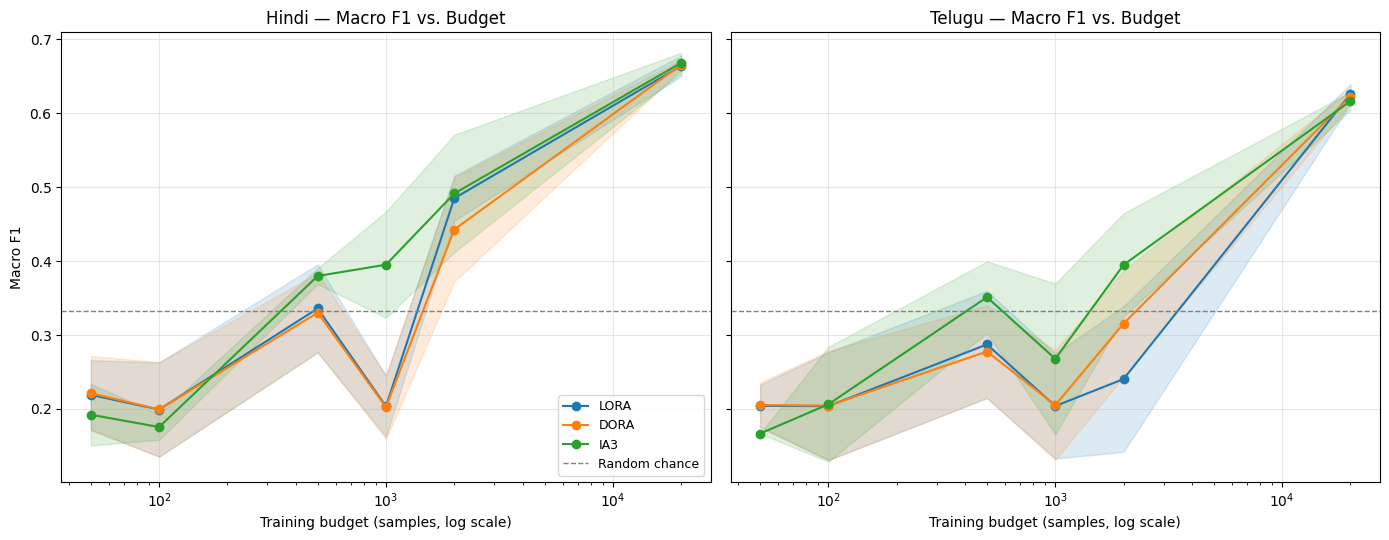

✓ Saved learning_curves.png


In [4]:
# ================================
# Learning curve plots — one per language, F1 vs budget, 3 methods, CI bands
# ================================
BUDGETS = [50, 100, 500, 1000, 2000, 20000]
METHODS = ["lora", "dora", "ia3"]
COLORS = {"lora": "#1f77b4", "dora": "#ff7f0e", "ia3": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, language, title in zip(axes, ["hi", "te"], ["Hindi", "Telugu"]):
    for method in METHODS:
        sub = summary[(summary.method == method) & (summary.language == language)].sort_values("budget")
        ax.plot(sub["budget"], sub["f1_mean"], marker="o", label=method.upper(), color=COLORS[method])
        ax.fill_between(
            sub["budget"],
            sub["f1_mean"] - sub["f1_ci95"],
            sub["f1_mean"] + sub["f1_ci95"],
            alpha=0.15, color=COLORS[method]
        )
    ax.set_xscale("log")
    ax.set_xlabel("Training budget (samples, log scale)")
    ax.set_title(f"{title} — Macro F1 vs. Budget")
    ax.axhline(0.333, color="gray", linestyle="--", linewidth=1, label="Random chance")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Macro F1")
axes[0].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/learning_curves.png", dpi=150)
plt.show()

print("✓ Saved learning_curves.png")

In [5]:
# ================================
# Crossover-point detection
# Per proposal: crossover = CIs stop overlapping AND ranking reverses,
# consistent across the budget progression
# ================================
def detect_crossovers(summary, language):
    lang_df = summary[summary.language == language].copy()
    budgets_sorted = sorted(lang_df.budget.unique())

    crossovers = []
    for i in range(len(budgets_sorted) - 1):
        b1, b2 = budgets_sorted[i], budgets_sorted[i + 1]

        row1 = lang_df[lang_df.budget == b1].set_index("method")
        row2 = lang_df[lang_df.budget == b2].set_index("method")

        # Rank methods by F1 at each budget
        rank1 = row1["f1_mean"].sort_values(ascending=False).index.tolist()
        rank2 = row2["f1_mean"].sort_values(ascending=False).index.tolist()

        if rank1 != rank2:
            # Check if CIs actually separate the reversed pair (not just noise)
            for m1, m2 in zip(rank1, rank1[1:]):
                f1_a, ci_a = row1.loc[m1, "f1_mean"], row1.loc[m1, "f1_ci95"]
                f1_b, ci_b = row1.loc[m2, "f1_mean"], row1.loc[m2, "f1_ci95"]
                separated_at_b1 = (f1_a - ci_a) > (f1_b + ci_b)

            crossovers.append({
                "language": language,
                "budget_before": b1,
                "budget_after": b2,
                "ranking_before": rank1,
                "ranking_after": rank2,
            })

    return crossovers

print("=== Hindi crossovers ===")
hi_crossovers = detect_crossovers(summary, "hi")
for c in hi_crossovers:
    print(f"  Between budget={c['budget_before']} and budget={c['budget_after']}: "
          f"{c['ranking_before']} -> {c['ranking_after']}")

print("\n=== Telugu crossovers ===")
te_crossovers = detect_crossovers(summary, "te")
for c in te_crossovers:
    print(f"  Between budget={c['budget_before']} and budget={c['budget_after']}: "
          f"{c['ranking_before']} -> {c['ranking_after']}")

print("\nNote: CI-overlap check is informational — with n=3 seeds, CIs are wide;")
print("treat 'crossover' claims as suggestive, and report CI widths alongside any claim.")

=== Hindi crossovers ===
  Between budget=100 and budget=500: ['dora', 'lora', 'ia3'] -> ['ia3', 'lora', 'dora']
  Between budget=2000 and budget=20000: ['ia3', 'lora', 'dora'] -> ['ia3', 'dora', 'lora']

=== Telugu crossovers ===
  Between budget=50 and budget=100: ['dora', 'lora', 'ia3'] -> ['ia3', 'dora', 'lora']
  Between budget=100 and budget=500: ['ia3', 'dora', 'lora'] -> ['ia3', 'lora', 'dora']
  Between budget=500 and budget=1000: ['ia3', 'lora', 'dora'] -> ['ia3', 'dora', 'lora']
  Between budget=2000 and budget=20000: ['ia3', 'dora', 'lora'] -> ['lora', 'dora', 'ia3']

Note: CI-overlap check is informational — with n=3 seeds, CIs are wide;
treat 'crossover' claims as suggestive, and report CI widths alongside any claim.


In [6]:
# ================================
# Ranking table per (language, budget) — the core result table for your report
# ================================
ranking_table = summary.pivot_table(index=["language", "budget"], columns="method", values="f1_mean")
ranking_table["best_method"] = ranking_table[METHODS].idxmax(axis=1)
display(ranking_table)

ranking_table.to_csv("/kaggle/working/ranking_table.csv")
print("✓ Saved ranking_table.csv")

method               dora       ia3      lora best_method
language budget                                          
hi       50      0.221293  0.192181  0.219057        dora
         100     0.199331  0.175501  0.199152        dora
         500     0.330174  0.379855  0.335923         ia3
         1000    0.202535  0.395131  0.203533         ia3
         2000    0.442721  0.491472  0.485044         ia3
         20000   0.665788  0.668206  0.664053         ia3
te       50      0.205323  0.166667  0.204097        dora
         100     0.204420  0.206277  0.203810         ia3
         500     0.277677  0.351163  0.287247         ia3
         1000    0.205164  0.267796  0.203917         ia3
         2000    0.315463  0.394947  0.240430         ia3
         20000   0.622666  0.616463  0.626213        lora

✓ Saved ranking_table.csv


In [7]:
# ================================
# Compute-efficiency comparison (trainable params, memory, time)
# Free deliverable — already logged per run
# ================================
compute_summary = df.groupby("method").agg(
    trainable_params=("trainable_params", "first"),
    avg_peak_memory_gb=("peak_gpu_memory_gb", "mean"),
    total_training_time_sec=("training_time_sec", "sum"),
).reset_index()

compute_summary["total_training_time_min"] = compute_summary["total_training_time_sec"] / 60
display(compute_summary)

compute_summary.to_csv("/kaggle/working/compute_efficiency.csv", index=False)

,method,trainable_params,avg_peak_memory_gb,total_training_time_sec,total_training_time_min
0,dora,906243,1.172144,3213.25,53.554167
1,ia3,657411,1.240206,2864.74,47.745667
2,lora,887811,1.156692,2323.66,38.727667


In [8]:
# ================================
# Does the ranking hold across languages? — the actual research question
# ================================
print("Best method per budget, Hindi vs Telugu:\n")
comparison = ranking_table.reset_index().pivot(index="budget", columns="language", values="best_method")
display(comparison)

agreement = (comparison["hi"] == comparison["te"]).mean()
print(f"\nRanking agreement across languages: {agreement*100:.1f}% of budgets")
print("(i.e., how often the same method wins in both Hindi and Telugu at the same budget)")

Best method per budget, Hindi vs Telugu:



language,hi,te
budget,,
50,dora,dora
100,dora,ia3
500,ia3,ia3
1000,ia3,ia3
2000,ia3,ia3
20000,ia3,lora



Ranking agreement across languages: 66.7% of budgets
(i.e., how often the same method wins in both Hindi and Telugu at the same budget)


In [9]:
# ================================
# Final summary printout — paste-ready for your report's Results section
# ================================
print("="*70)
print("SUMMARY FOR REPORT")
print("="*70)
print(f"\nTotal configurations run: {len(df)}")
print(f"Collapsed (random-chance) runs: {len(collapsed)} ({100*len(collapsed)/len(df):.1f}%) — see collapsed_runs.csv")
print(f"\nRanking agreement between Hindi and Telugu across budgets: {agreement*100:.1f}%")
print(f"\nCrossovers detected — Hindi: {len(hi_crossovers)}, Telugu: {len(te_crossovers)}")
print("\nFiles saved to /kaggle/working/:")
print("  - summary_with_ci.csv       (mean/std/95% CI per method×language×budget)")
print("  - learning_curves.png       (F1 vs budget, 2 languages, CI bands)")
print("  - ranking_table.csv         (best method per language×budget)")
print("  - compute_efficiency.csv    (params/memory/time per method)")
print("  - collapsed_runs.csv        (documented instability cases)")

SUMMARY FOR REPORT

Total configurations run: 108
Collapsed (random-chance) runs: 19 (17.6%) — see collapsed_runs.csv

Ranking agreement between Hindi and Telugu across budgets: 66.7%

Crossovers detected — Hindi: 2, Telugu: 4

Files saved to /kaggle/working/:
  - summary_with_ci.csv       (mean/std/95% CI per method×language×budget)
  - learning_curves.png       (F1 vs budget, 2 languages, CI bands)
  - ranking_table.csv         (best method per language×budget)
  - compute_efficiency.csv    (params/memory/time per method)
  - collapsed_runs.csv        (documented instability cases)
